In [1]:
import retinanalysis as ra
# ra.djconnect()
# ra.populate_database()
import importlib
import pandas as pd
import numpy as np
import xarray as xr
display(ra.settings.mea_config)
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
# ra.database_pop.reload_celltypefiles()
# ra.database_utils.populate_database()
import sys
sys.path.append('/Users/racheloaks-leaf/Desktop/analysis_util/splitFieldNoise')
sys.path.append('/Users/racheloaks-leaf/Desktop/analysis_util/general')
import splitField_util as sfu
import general_util as gu
import importlib
importlib.reload(sfu)
importlib.reload(gu)
importlib.reload(ra)

/Users/racheloaks-leaf/anaconda3/envs/analysis2/lib/python3.11/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2025-08-07 12:22:16,062][INFO]: DataJoint 0.14.4 connected to root@127.0.0.1:3306


{'data': '/Volumes/RachelSSD/mea/analysis/',
 'analysis': '/Volumes/RachelSSD/mea/analysis/',
 'h5': '/Volumes/RachelSSD/mea/h5/',
 'meta': '/Volumes/RachelSSD/mea/datajoint_testbed/mea/meta/',
 'tags': '/Volumes/RachelSSD/mea/datajoint_testbed/mea/tags/',
 'user': 'roaksleaf'}

<module 'retinanalysis' from '/Users/racheloaks-leaf/Desktop/retinanalysis/src/retinanalysis/__init__.py'>

In [2]:
to_query = ['CheckerboardNoiseProjectRachel']
experiment_query = ra.get_datasets_from_protocol_names(to_query)
experiment_query.tail()


Found 1 protocols matching "checkerboardnoiseprojectrachel":
['edu.washington.riekelab.rachel.protocols.CheckerboardNoiseProjectRachel']

Found 14 experiments, 51 epoch blocks.



,exp_name,datafile_name,NDF,chunk_name,protocol_name,is_mea,data_dir,group_label,experiment_id,protocol_id,group_id,block_id,chunk_id
46,20250715H,data008,1.0,split_field2,edu.washington.riekelab.rachel.protocols.Check...,1,20250715H/data008,split field noise 10 R*,129,64,2334,3366,520
47,20250715H,data011,0.5,split_field3,edu.washington.riekelab.rachel.protocols.Check...,1,20250715H/data011,split field noise 10 R*,129,64,2337,3369,523
48,20250715H,data012,0.5,split_field3,edu.washington.riekelab.rachel.protocols.Check...,1,20250715H/data012,split field noise 10 R*,129,64,2337,3370,523
49,20250710H,data002,2.0,split_field,edu.washington.riekelab.rachel.protocols.Check...,1,20250710H/data002,split field noise 3 R*,132,64,2367,3408,540
50,20250710H,data003,2.0,split_field,edu.washington.riekelab.rachel.protocols.Check...,1,20250710H/data003,split field noise 3 R*,132,64,2367,3409,540


In [3]:
#want to do dedup pre-typing, so no response file right now
exp_name = experiment_query.loc[47, 'exp_name']
datafile_name = experiment_query.loc[47,'datafile_name']
chunk_name = experiment_query.loc[47,'chunk_name']

# Create stim, response, analysis_chunk and pipeline class
pipeline=ra.create_mea_pipeline(exp_name, datafile_name)
stim = pipeline.stim_block
response = pipeline.response_block
analysis = pipeline.analysis_chunk

Initializing StimBlock for 20250715H block 3369
Nearest noise chunk for data011 is chunk1 with distance 380 minutes.

Initializing ResponseBlock for 20250715H block 3369
Loading frame monitor data from /Volumes/RachelSSD/mea/h5/20250715H.h5 ...
Loaded (60, 31000) frame_data.

Loading VCD from /Volumes/RachelSSD/mea/analysis/20250715H/data011/kilosort2.5 ...
VCD loaded with 439 cells.

Using chunk1 for AnalysisChunk

Loading VCD from /Volumes/RachelSSD/mea/analysis/20250715H/chunk1/kilosort2.5 ...
VCD loaded with 444 cells.

Loaded spatial maps for channels [0, 2] and 444 cells of shape (95, 152, 2)
Spatial maps have been padded to align with RF parameters.

Cluster matching 20250715H chunk1 with CheckerboardNoiseProjectRachel ...
43.69% matched, 56.31% unmatched.



In [4]:
stim.df_epochs['microns_per_pixel'] = analysis.microns_per_pixel
stim.df_epochs['canvas_size'] = [analysis.canvas_size for _ in range(len(stim.df_epochs))]

In [5]:
importlib.reload(ra)
stim.regenerate_stimulus(exp_name=stim.exp_name, str_pkg_dir='/Users/racheloaks-leaf/Desktop/rachel-package/', b_noise_only=True)
# d_stim = stim.regenerate_stimulus(exp_name='20250807', str_pkg_dir='/Users/racheloaks-leaf/Desktop/rachel-package/', b_noise_only=False)

Regenerating stimulus for epochs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59] in block: 3369
Using regeneration function: make_checkerboard_noise_project
Starting matlab engine for stim regen.
Started engine and added pkg to path.
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using 

In [31]:
importlib.reload(sfu)
stim_frames = sfu.regenerateSplitField(stim, noise_only=True, save=False)


using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 function
using Aug62025 f

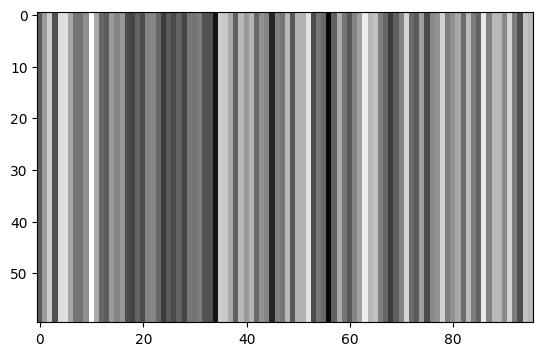

In [32]:
plt.imshow(stim_frames[:, :, 1000, 0], cmap='gray', vmin=0, vmax=255)

<StemContainer object of 3 artists>

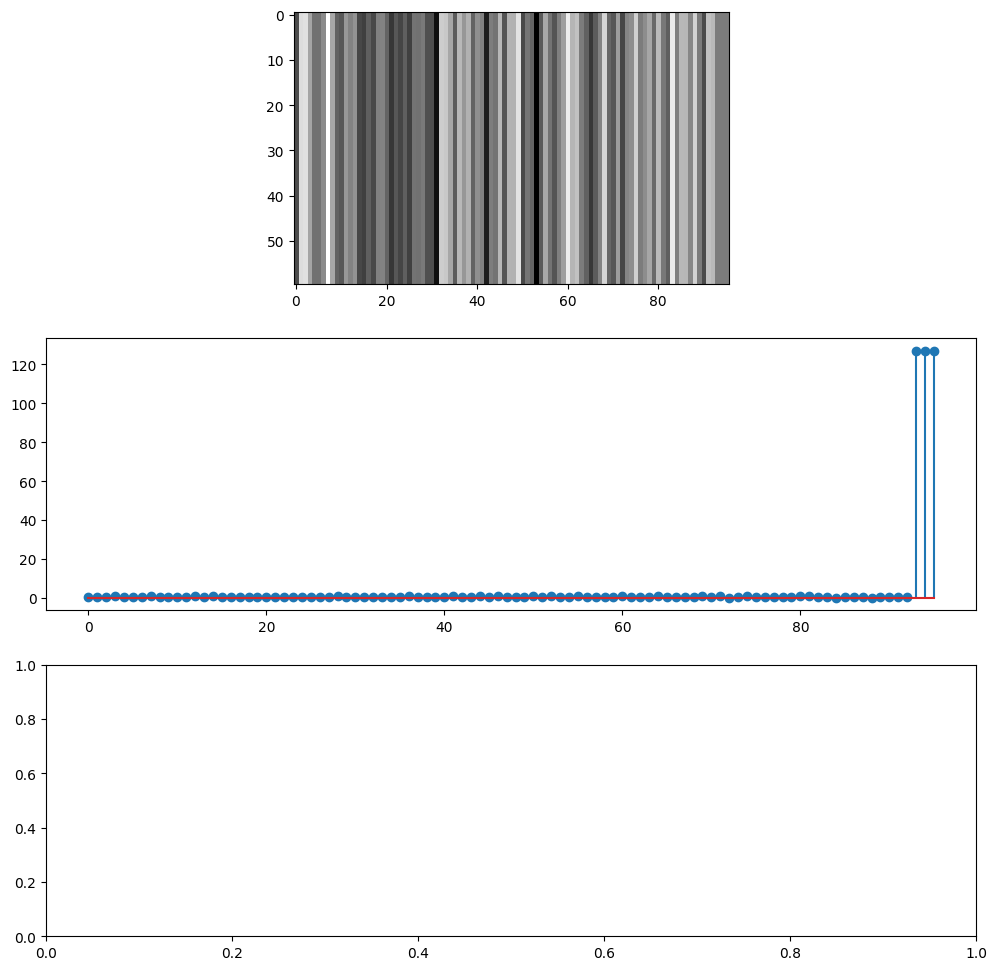

In [6]:
fig, ax = plt.subplots(3,1, figsize=(12,12))
ax[0].imshow(stim.stim_data['stim_frames'][:,:,1000,0], cmap='gray')
ax[1].stem(stim.stim_data['line_mat'][:, 500,0])
# ax[2].plot(stim.stim_data['contrast_mat'][:,0])


In [7]:
pre_frames = np.round((stim.df_epochs.loc[0]['preTime']/1e3) * 60).astype(int)
tail_frames = np.round((stim.df_epochs.loc[0]['tailTime']/1e3) * 60).astype(int)
print(pre_frames, tail_frames)

30 30


In [8]:
response.bin_spike_times_by_frames()

Binning spikes for cells:   0%|          | 0/439 [00:00<?, ?it/s]

Mean frame rate: 59.95 Hz



In [9]:
locus = 88

cell_id = response.df_spike_times.query('cell_type == "OnP"').loc[locus]['cell_id']
cell_df = response.df_spike_times.query('cell_id == @cell_id')
noise_id = cell_df['noise_id'].values[0]
params_df = analysis.df_cell_params.query('cell_id == @cell_id')

In [10]:
scaling_factor = (stim.d_epoch_block_params['stixelSize'] / analysis.microns_per_stixel)
x_offset = stim.d_epoch_block_params['xOffset'] * analysis.microns_per_pixel / analysis.microns_per_stixel
print(x_offset)
params_df.loc[:, 'center_x'] /= scaling_factor
# params_df.loc[:, 'center_x'] -= x_offset
params_df.loc[:, 'center_y'] /= scaling_factor
params_df.loc[:, 'std_x'] /= scaling_factor
params_df.loc[:, 'std_y'] /= scaling_factor

-4.833333333333333


In [11]:
stim_frames = np.moveaxis(stim.stim_data['stim_frames'], 2, 0)

In [12]:
frames_ms = stim_frames - np.mean(stim_frames)

In [13]:
stim_epochs = [frames_ms[:-1, :, :, i] for i in range(stim_frames.shape[3])]
response_epochs = [cell_df['binned_spikes'].values[0][i,:] for i in range(cell_df['binned_spikes'].values[0].shape[0])]

ex_sta = gu.compute_sta_epochs(stim_epochs, response_epochs, window=25)
ex_sta = np.moveaxis(ex_sta, 0, 2)

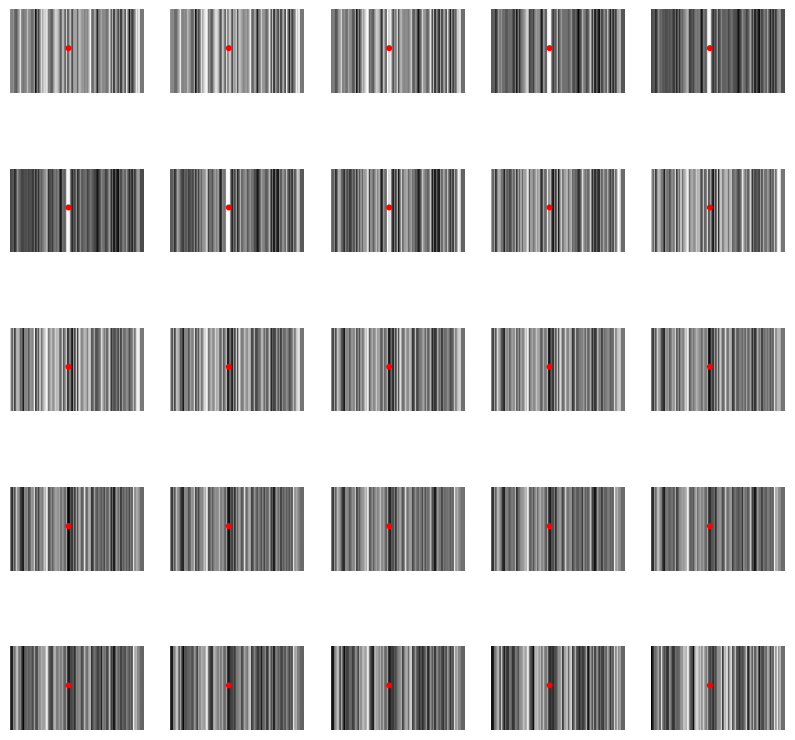

In [14]:
from matplotlib.patches import Ellipse
fig, ax = plt.subplots(5,5, figsize=(10,10), sharex=True, sharey=True)
for i in range(5):
    for j in range(5):
        ell = Ellipse((params_df['center_x'].values[0], params_df['center_y'].values[0]), params_df['std_x'].values[0]*2, params_df['std_y'].values[0]*2, angle=params_df['rot'].values[0], color='red', fill=True)
        ax[i, j].imshow(ex_sta[:, :, i*5 + j], cmap='gray')
        ax[i, j].add_patch(ell)
        ax[i, j].axis('off')